Import de dataset y librerias

In [116]:
import pandas as pd
import numpy as np
from skforecast.recursive import ForecasterRecursive
import shap
import matplotlib.pyplot as plt
from skforecast.plot import set_dark_theme
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from skforecast.model_selection import grid_search_forecaster
from sklearn.preprocessing import MinMaxScaler
from skforecast.preprocessing import RollingFeatures
import seaborn as sns

dataset = 'CTC_processed.csv'
                              
data = pd.read_csv(
        dataset,
        sep=";",
        low_memory=False,
)

data = data.sort_index() #Ordenar por fecha

data["datetime"] = pd.to_datetime(data["datetime"], dayfirst=True, errors="coerce") #convertimos time a datatime
data["month"] = data["datetime"].dt.month
data["day"] = data["datetime"].dt.day
data["hour"] = data["datetime"].dt.hour
data["minute"] = data["datetime"].dt.minute

datetime = data["datetime"] #guardamos la columna Time en una variable
data.drop(columns=["datetime"], inplace=True) #eliminamos la columna Time

exogenas = ['temperature', 'solarRad', 'humedad', 'windSpeed', 'rain', 'pressure', 'month', 'day', 'hour', 'minute']

Dividimos en train y test

In [117]:
train_size = int(len(data) * 0.8)

data_train = data.iloc[:train_size]   
data_test  = data.iloc[train_size:]   

Escalamos los datos.

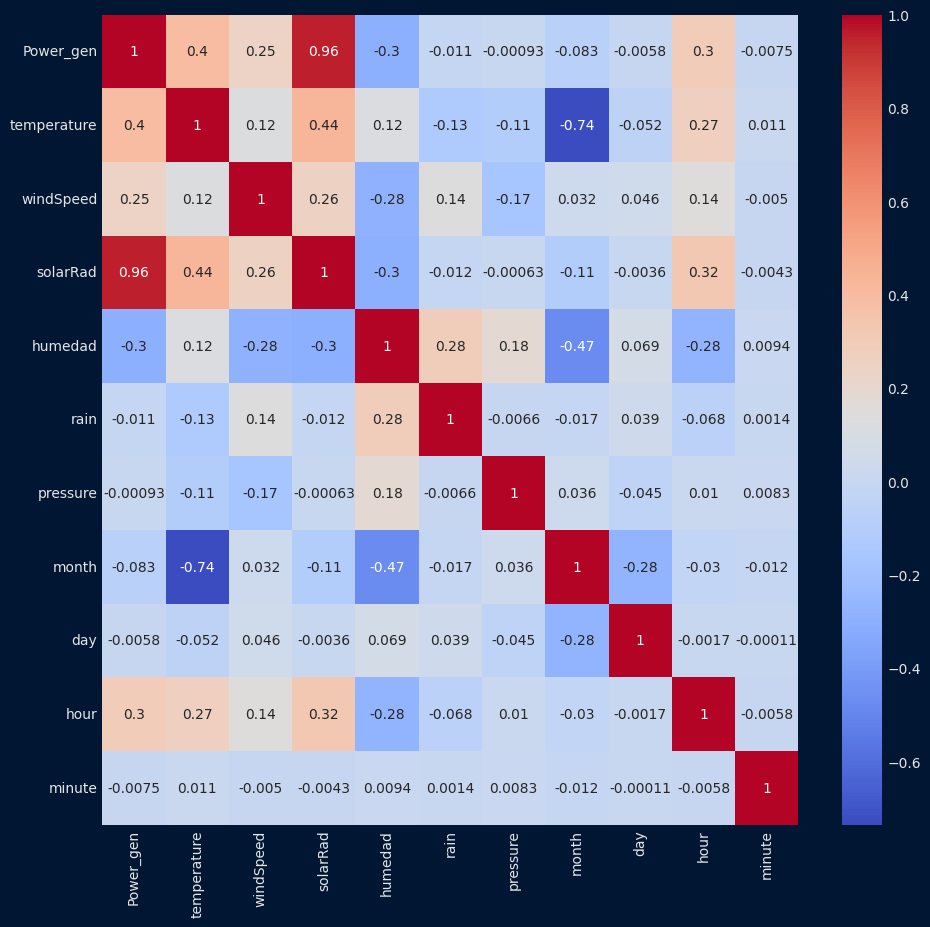

In [118]:
scaler = MinMaxScaler()
#entrenamiento
train_scaled = data_train.copy()
train_scaled[exogenas] = scaler.fit_transform(data_train[exogenas])

corr_df = train_scaled.corr(method ='spearman')

#test
test_scaled = data_test.copy()
test_scaled[exogenas] = scaler.fit_transform(data_test[exogenas])

corr_df = test_scaled.corr(method ='spearman')

plt.figure(figsize=(10, 10))
sns.heatmap(corr_df, annot=True, cmap='coolwarm')

plt.show()

Obtenemos los parámetros óptimos del modelo

In [119]:
'''from skforecast.recursive import ForecasterRecursive
from skforecast.model_selection import random_search_forecaster
from xgboost import XGBRegressor
from skforecast.model_selection import TimeSeriesFold

param_distributions = {
    'learning_rate': [0.01, 0.6],
    'max_depth': [3, 9],
    'n_estimators': [200, 900],
    'subsample': [0.6, 1.0]
}

forecaster = ForecasterRecursive(
    estimator = XGBRegressor(
        n_jobs=-1,
        tree_method="hist"   # mucho más rápido
    ),
    lags = 7
)

cv = TimeSeriesFold(
    initial_train_size = int(len(data_train) * 0.2),  # más grande para menos folds
    steps = 366,
    gap = 0
)

search_result = random_search_forecaster(
    forecaster      = forecaster,
    y               = data_train['Power_gen'],
    exog            = data_train[exogenas],
    param_distributions = param_distributions,
    n_iter          = 10,          # solo 10 combinaciones
    cv              = cv,
    metric          = 'mean_absolute_error',
    return_best     = True,
    verbose         = True
)'''


'from skforecast.recursive import ForecasterRecursive\nfrom skforecast.model_selection import random_search_forecaster\nfrom xgboost import XGBRegressor\nfrom skforecast.model_selection import TimeSeriesFold\n\nparam_distributions = {\n    \'learning_rate\': [0.01, 0.6],\n    \'max_depth\': [3, 9],\n    \'n_estimators\': [200, 900],\n    \'subsample\': [0.6, 1.0]\n}\n\nforecaster = ForecasterRecursive(\n    estimator = XGBRegressor(\n        n_jobs=-1,\n        tree_method="hist"   # mucho más rápido\n    ),\n    lags = 7\n)\n\ncv = TimeSeriesFold(\n    initial_train_size = int(len(data_train) * 0.2),  # más grande para menos folds\n    steps = 366,\n    gap = 0\n)\n\nsearch_result = random_search_forecaster(\n    forecaster      = forecaster,\n    y               = data_train[\'Power_gen\'],\n    exog            = data_train[exogenas],\n    param_distributions = param_distributions,\n    n_iter          = 10,          # solo 10 combinaciones\n    cv              = cv,\n    metric     

Evolucion de las variables exogenas

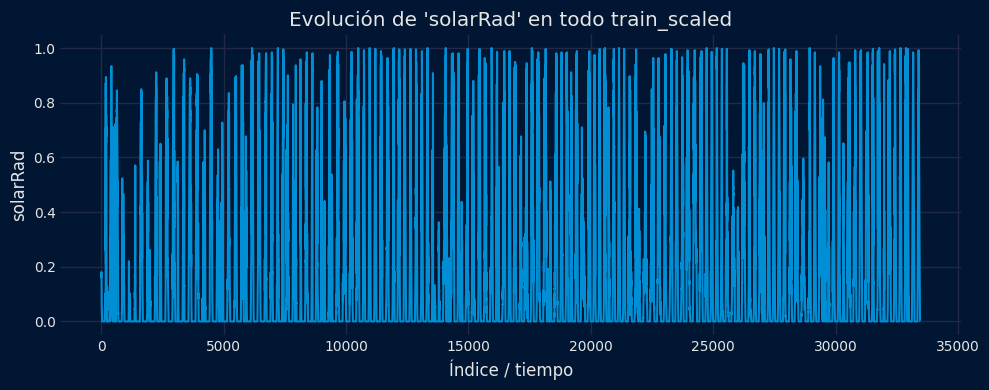

In [120]:
var = "solarRad"  #variable a analizar

plt.figure(figsize=(10, 4))
plt.plot(train_scaled.index, train_scaled[var])
plt.xlabel("Índice / tiempo")
plt.ylabel(var)
plt.title(f"Evolución de '{var}' en todo train_scaled")
plt.grid(True)
plt.tight_layout()
plt.show()


Valores de las exogenas para un dia en concreto

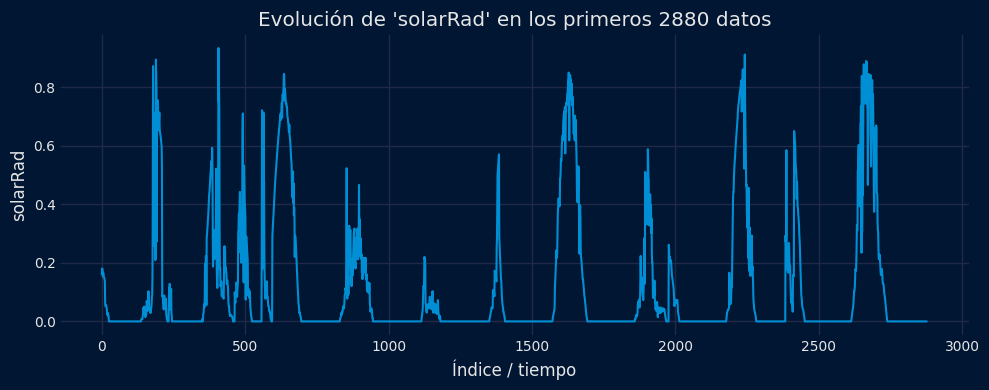

In [121]:
pasos_dia = 10 *(24 * 60 // 5)   #288 primer dia de data_train (datos cada 5 minutos)

plt.figure(figsize=(10, 4))
plt.plot(train_scaled.index[:pasos_dia], train_scaled[var].iloc[:pasos_dia])
plt.xlabel("Índice / tiempo")
plt.ylabel(var)
plt.title(f"Evolución de '{var}' en los primeros {pasos_dia} datos")
plt.grid(True)
plt.tight_layout()
plt.show()


El primer paso es crear el forecaster.

In [122]:
window_features = RollingFeatures(
                      stats        = ['mean', 'min', 'max'],
                      window_sizes = [20, 20, 20]
                  )

forecaster = ForecasterRecursive(
    estimator = XGBRegressor(learning_rate = 0.01, max_depth = 9, n_estimators = 400, subsample = 0.6, random_state = 42, base_score = 0.0,
                             reg_alpha = 0.0, reg_lambda = 1.0, min_child_weight=1, colsample_bytree=0.8),
    lags = 7,
    window_features=window_features
)

forecaster

=================== 
ForecasterRecursive 
=================== 
Estimator: XGBRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: ['roll_mean_20', 'roll_min_20', 'roll_max_20'] 
Window size: 20 
Series name: None 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: None 
Training index type: None 
Training index frequency: None 
Estimator parameters: 
    {'objective': 'reg:squarederror', 'base_score': 0.0, 'booster': None,
    'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None,
    'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None,
    'enable_categorical': False, 'eval_metric': None, 'feature_types': None,
    'feature_weights': None, 'gamma': None, 'grow_policy': None,
    'importance_type': None, 'interaction_constraints': None, 'learning_rate':
    0.01, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None,
    'max_delta_step': None, 'max_depth': 9, 'max_leaves': None,
    'min_child_weight': 1, 'missing': nan, 'monotone_constraints': None,
    'multi_strategy': None, 'n_estimators': 400, 'n_jobs': None,
    'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 0.0,
    'reg_lambda': 1.0, 'sampling_method': None, 'scale_pos_weight': None,
    'subsample': 0.6, 'tree_method': None, 'validate_parameters': None,
    'verbosity': None} 
fit_kwargs: {} 
Creation date: 2026-01-02 12:52:52 
Last fit date: None 
Skforecast version: 0.19.0 
Python version: 3.14.1 
Forecaster id: None

Entrenamos el modelo.

In [123]:
X_test, y_test = forecaster.create_train_X_y(y=test_scaled['Power_gen'], exog=test_scaled[exogenas])
X_train, y_train = forecaster.create_train_X_y(y=train_scaled['Power_gen'], exog=train_scaled[exogenas])

forecaster.fit(y=train_scaled['Power_gen'], exog=train_scaled[exogenas])

Comprobamos si hay overfitting y entrenamos. El early_stop = 50, por lo que el modelo se detendrá cuando no haya mejorado en 50 iteraciones el valor de validación. La reducción del error segun avanza el train indica la efectiva eliminacion de perdidas. Alcanza una estabilización al final, lo que significa el final del proceso de entrenamiento. El comportamiento del modelo en entrenamiento y validacion es consistente, lo que confirma la no presencia de sobreentrenamiento en los datos.

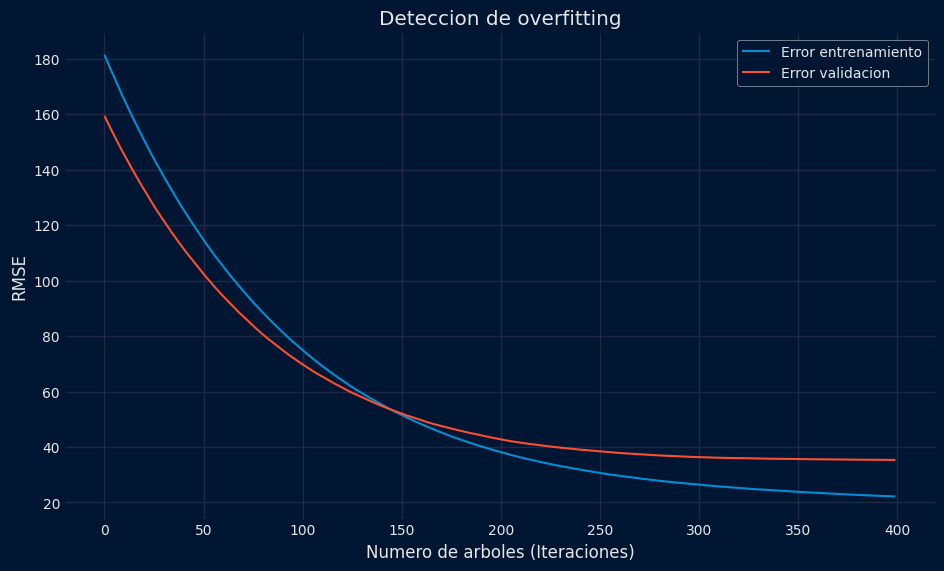

In [124]:
model = forecaster.estimator

model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose = False)

results = model.evals_result()

#print(f"Mejor iteracion: {forecaster.estimator.best_iteration}")
plt.figure(figsize=(10,6))
plt.plot(results['validation_0']['rmse'], label='Error entrenamiento')
plt.plot(results['validation_1']['rmse'], label='Error validacion')
plt.xlabel('Numero de arboles (Iteraciones)')
plt.ylabel('RMSE')
plt.title('Deteccion de overfitting')
plt.legend()
plt.show()

Obtenemos las variables mas importantes en el forecaster

In [125]:
importancia = forecaster.get_feature_importances()
print(importancia)

         feature  importance
0          lag_1    0.561734
1          lag_2    0.138613
11      solarRad    0.111412
18          hour    0.041565
16         month    0.017704
2          lag_3    0.015522
14          rain    0.010439
8    roll_min_20    0.010165
6          lag_7    0.009305
9    roll_max_20    0.009198
5          lag_6    0.009171
7   roll_mean_20    0.008463
17           day    0.008348
4          lag_5    0.008327
3          lag_4    0.008078
12       humedad    0.007471
10   temperature    0.007063
15      pressure    0.006087
13     windSpeed    0.006067
19        minute    0.005267


Usamos SHAP para crear los datos de entrenamiento

In [126]:
x_train, y_train = forecaster.create_train_X_y(
    y=train_scaled['Power_gen'],
    exog=train_scaled[exogenas]
)

print(x_train.head()) 
print(y_train.head()) 

    lag_1  lag_2  lag_3  lag_4  lag_5  lag_6  lag_7  roll_mean_20  \
20    0.0   39.0   39.0   39.0   39.0   39.0   39.0         53.45   
21    0.0    0.0   39.0   39.0   39.0   39.0   39.0         50.20   
22    0.0    0.0    0.0   39.0   39.0   39.0   39.0         46.70   
23    0.0    0.0    0.0    0.0   39.0   39.0   39.0         42.60   
24    0.0    0.0    0.0    0.0    0.0   39.0   39.0         38.70   

    roll_min_20  roll_max_20  temperature  solarRad  humedad  windSpeed  rain  \
20          0.0         82.0     0.545107  0.022187     0.00   0.879562   0.0   
21          0.0         82.0     0.541284  0.025357     0.00   0.645985   0.0   
22          0.0         82.0     0.541284  0.028526     0.00   0.762774   0.0   
23          0.0         78.0     0.545107  0.017433     0.00   0.879562   0.0   
24          0.0         70.0     0.548930  0.017433     0.02   0.879562   0.0   

    pressure  month       day      hour    minute  
20  0.181818    0.0  0.766667  0.695652  0.847

Explainer del SHAP

In [ ]:
explainer = shap.Explainer(forecaster.estimator)

#50% de los datos de entrenamiento
rng = np.random.default_rng(42)
sample_indices = rng.choice(x_train.index, size=int(len(x_train) * 0.5), replace=False)
x_train_sample = x_train.loc[sample_indices,:]
shap_values = explainer.shap_values(x_train_sample)

Grafica resumen de SHAP

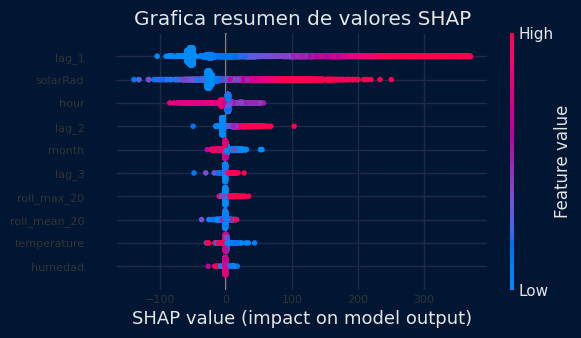

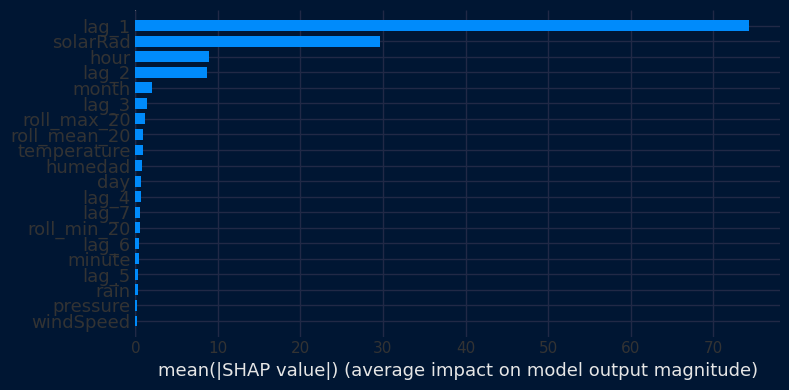

In [ ]:
shap.initjs()
shap.summary_plot(shap_values, x_train_sample, max_display=10, show=False)
fig, ax = plt.gcf(), plt.gca()
ax.set_title('Grafica resumen de valores SHAP')
ax.tick_params(labelsize=8)
fig.set_size_inches(6,3)
plt.show()


plt.figure()
shap.summary_plot(shap_values, x_train, plot_type="bar", plot_size=(8, 4))
plt.show()

Grafica de dependencia

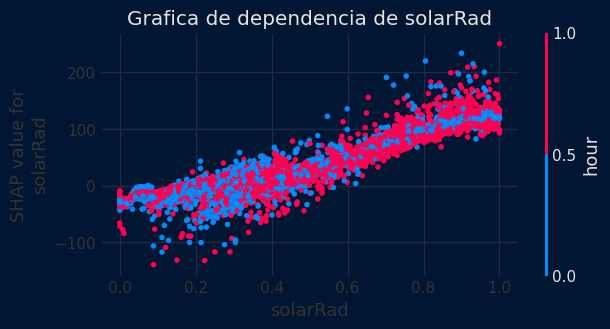

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.set_title('Grafica de dependencia de solarRad')

shap.dependence_plot("solarRad", shap_values, x_train_sample, ax=ax)
plt.show()

Primero, veremos las explicaciones de SHAP para predicciones de las proximas 8364 muestras (data_test)

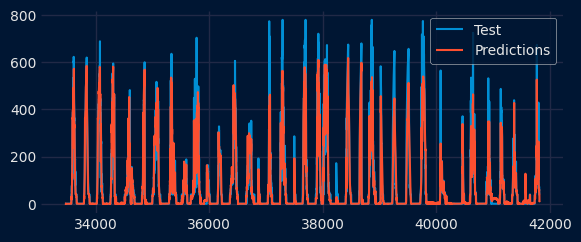

In [ ]:
pred = forecaster.predict(steps=len(test_scaled), exog=test_scaled[exogenas])

set_dark_theme()
fig, ax = plt.subplots(figsize=(6, 2.5))
test_scaled['Power_gen'].plot(ax=ax, label='Test')
pred.plot(ax=ax, label='Predictions', linestyle='-')
ax.set_xlabel(None)
ax.legend()
plt.show()

Graficas de dependencia parcial.

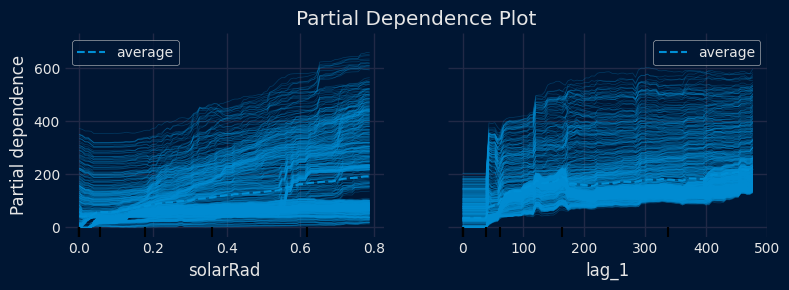

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))
pd.plots = PartialDependenceDisplay.from_estimator(
    estimator = forecaster.estimator,
    X         = x_train,
    features  = ["solarRad", "lag_1"],
    kind      = 'both',
    ax        = ax,
)
ax.set_title("Partial Dependence Plot")
fig.tight_layout()
plt.show()

Metricas de la prediccion

In [ ]:
y_test = test_scaled['Power_gen'].iloc[:len(pred)]

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Coeficiente de determinación (R^2): {r2:.4f}")

Mean Absolute Error (MAE): 16.5822
Mean Squared Error (MSE): 1631.2246
Root Mean Squared Error (RMSE): 40.3884
Coeficiente de determinación (R^2): 0.9211


Añadimos una variable extra, la irrandiancia ideal, de forma que ayude al modelo a saber hasta que valor podría llegar a ascender.

In [ ]:
t_min = data["hour"] * 60 + data["minute"]
t_day = 24 * 60

t_mid = 13 * 60   
x = (t_min - t_mid) / (t_day / 2)   

irr_ideal_norm = np.clip(1 - x**2, 0, 1) 

IRR_MAX = 631 #maxima solarRad en el dataset 
train_scaled["irr_ideal"] = IRR_MAX * irr_ideal_norm
test_scaled["irr_ideal"] = IRR_MAX * irr_ideal_norm

In [ ]:
exogenas = ['temperature', 'solarRad', 'humedad', 'windSpeed',
            'rain', 'pressure', 'month', 'day', 'hour', 'minute',
             'irr_ideal']

forecaster.fit(y=train_scaled["Power_gen"],
               exog=train_scaled[exogenas])

pred = forecaster.predict(steps=len(test_scaled),
                          exog=test_scaled[exogenas])


Nuevas métricas de la predicción, ligeramente mejores.

In [ ]:
y_test = test_scaled['Power_gen'].iloc[:len(pred)]

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Coeficiente de determinación (R^2): {r2:.4f}")

Mean Absolute Error (MAE): 16.3929
Mean Squared Error (MSE): 1593.0895
Root Mean Squared Error (RMSE): 39.9135
Coeficiente de determinación (R^2): 0.9229


Predicción para un día

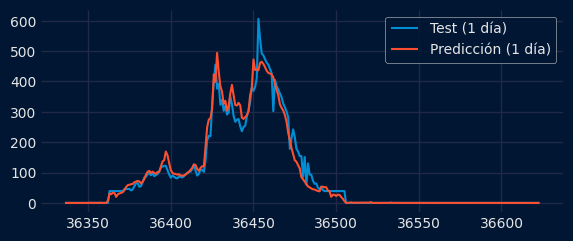

In [ ]:
pasos_dia = 24 * 60 // 5   #288

#Ahora recorta solo un día para graficar
idx_ini = 10 * pasos_dia #dia en concreto
y_real_dia = test_scaled['Power_gen'].iloc[idx_ini:idx_ini + pasos_dia]
pred_dia   = pred.iloc[idx_ini:idx_ini + pasos_dia]

fig, ax = plt.subplots(figsize=(6, 2.5))
y_real_dia.plot(ax=ax, label='Test (1 día)')
pred_dia.plot(ax=ax, label='Predicción (1 día)', linestyle='-')
ax.set_xlabel(None)
ax.legend()
plt.show()


Predicción para dos días

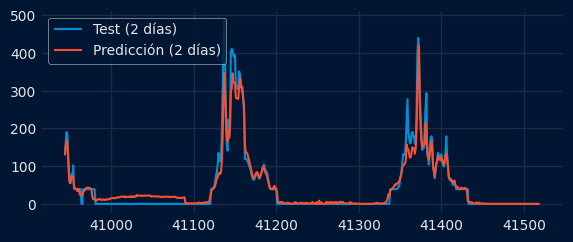

In [ ]:
pasos_dia = 2 * (24 * 60 // 5)   #288

#Ahora recorta solo un día para graficar
idx_ini = 13 * pasos_dia #dia en concreto
y_real_dia = test_scaled['Power_gen'].iloc[idx_ini:idx_ini + pasos_dia]
pred_dia   = pred.iloc[idx_ini:idx_ini + pasos_dia]

fig, ax = plt.subplots(figsize=(6, 2.5))
y_real_dia.plot(ax=ax, label='Test (2 días)')
pred_dia.plot(ax=ax, label='Predicción (2 días)', linestyle='-')
ax.set_xlabel(None)
ax.legend()
plt.show()

Comparativa realidad vs prediccion

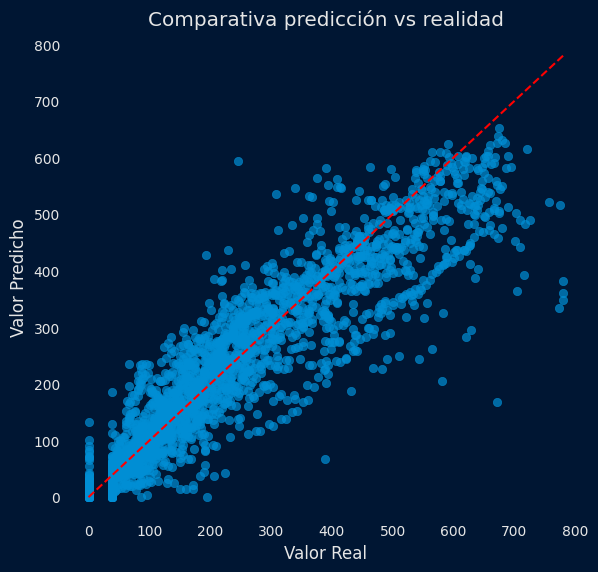

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  #linea de igualdad
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title('Comparativa predicción vs realidad')
plt.grid()
plt.show()

Tratamiento de ceros

In [ ]:
error_cero = np.where((y_test == 0) & (pred > 80))[0] #errores en 0 mayores que el MAE

print(f"Se encontraron {len(error_cero)} errores en el valor cero")

print(pred.iloc[error_cero])
#pred.iloc[error_cero] = 0

Se encontraron 4 errores en el valor cero
35956    132.536026
38685     83.916946
41572    101.302628
41573     90.685783
Name: pred, dtype: float64
